# Autonomous Geometric Engine (AGE)
### Manifold-envelope clustering with out-of-sample prediction and OOD rejection

**Honest abstract.** AGE is a scikit-learn–compatible clustering estimator that
adds two capabilities standard density clustering lacks in one object:
a real `predict()` for unseen points, and principled out-of-distribution (OOD)
rejection (label `-1`). It density-clusters with OPTICS, then wraps each
discovered cluster in a manifold envelope (KD-tree + adaptive-gamma RBF Nyström
map + a local acceptance radius).

**What AGE is — and is not.** Every number in this notebook is computed at run
time; nothing is hardcoded. We report results *including where AGE loses*:

- Clustering quality equals plain OPTICS and is beaten by K-Means on Iris/Wine —
  the envelope layer does not improve partition quality.
- OOD rejection works but is matched by a ~5-line kNN-distance baseline and by
  One-Class SVM. It is a cleanly integrated textbook capability, not a new detector.
- Runtime is dominated by OPTICS (~O(N^1.4) empirically), not sub-linear.

AGE's genuine niche is **integration + a usable `predict()`/reject on new data**,
delivered as one correct, transparent, reproducible artifact. See
`README_AGE_FINDINGS.md` for the full review and the list of errors corrected
from the original exploratory notebook.

In [1]:
# Setup
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import OPTICS, KMeans, DBSCAN
from sklearn.kernel_approximation import Nystroem
from sklearn.neighbors import KDTree
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, roc_auc_score
from sklearn.datasets import load_iris, load_wine
from scipy.spatial.distance import pdist

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif"})
SEED = 42
print("Environment ready.")

Environment ready.


## The engine

The class below is the canonical AGE, identical to `age.py` in this repo
(inlined here so the notebook runs standalone). It is unsupervised: **no labels
are ever passed to `fit`**. Labels appear later only to *score* results.

In [2]:
class AGE(BaseEstimator, ClusterMixin):
    """Density clustering (OPTICS) + manifold envelopes for predict() + OOD reject."""

    def __init__(self, min_samples=5, xi=0.05, n_components=15,
                 envelope_quantile=0.98, envelope_scale=4.0):
        self.min_samples = min_samples
        self.xi = xi
        self.n_components = n_components
        self.envelope_quantile = envelope_quantile
        self.envelope_scale = envelope_scale

    def _adaptive_gamma(self, pts):
        if len(pts) < 2:
            return 0.5
        d = pdist(pts, metric="euclidean")
        med = np.median(d) if d.size else 0.0
        return 1.0 / (2.0 * med ** 2) if med > 1e-8 else 0.5

    def _build_envelope(self, pts):
        tree = KDTree(pts, leaf_size=40)
        if len(pts) > 1:
            nn = tree.query(pts, k=2)[0][:, 1]
            local_thr = np.quantile(nn, self.envelope_quantile) * self.envelope_scale
        else:
            local_thr = np.inf
        n_comp = min(self.n_components, len(pts))
        fmap = Nystroem(kernel="rbf", gamma=self._adaptive_gamma(pts),
                        n_components=n_comp, random_state=42)
        pts_t = fmap.fit_transform(pts)
        return {"tree": tree, "fmap": fmap,
                "kernel_center": pts_t.mean(axis=0),
                "local_threshold": max(float(local_thr), 1e-9)}

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.labels_ = OPTICS(min_samples=self.min_samples, xi=self.xi,
                              metric="euclidean").fit_predict(X)
        groups = sorted(set(self.labels_) - {-1})
        self.n_clusters_ = len(groups)
        self.manifolds_ = {g: self._build_envelope(X[self.labels_ == g]) for g in groups}
        return self

    def fit_predict(self, X, y=None):
        return self.fit(X).labels_

    def predict(self, X_new):
        X_new = np.asarray(X_new, dtype=float)
        ids = sorted(self.manifolds_)
        if not ids:
            return np.full(len(X_new), -1, dtype=int)
        scores = np.full((len(X_new), len(ids)), np.inf)
        for j, g in enumerate(ids):
            m = self.manifolds_[g]
            nearest = m["tree"].query(X_new, k=1)[0].ravel()
            xt = m["fmap"].transform(X_new)
            kdist = np.linalg.norm(xt - m["kernel_center"], axis=1)
            kdist[nearest > m["local_threshold"]] = np.inf
            scores[:, j] = kdist
        best = np.argmin(scores, axis=1)
        out = np.array([ids[b] for b in best], dtype=int)
        out[np.min(scores, axis=1) == np.inf] = -1
        return out

    def decision_distance(self, X_new):
        X_new = np.asarray(X_new, dtype=float)
        ids = sorted(self.manifolds_)
        if not ids:
            return np.full(len(X_new), np.inf)
        d = np.full((len(X_new), len(ids)), np.inf)
        for j, g in enumerate(ids):
            d[:, j] = self.manifolds_[g]["tree"].query(X_new, k=1)[0].ravel()
        return d.min(axis=1)

print("AGE defined.")

AGE defined.


## 1. Clustering quality on real data (unsupervised)

ARI vs ground truth on UCI Iris and Wine. No method receives labels; labels are
used only to score the partition. **Expected outcome: AGE equals OPTICS and is
beaten by K-Means.** We show this rather than hide it.

In [3]:
rows = []
for name, (X, y), eps in [("UCI Iris", load_iris(return_X_y=True), 0.8),
                          ("UCI Wine", load_wine(return_X_y=True), 2.2)]:
    Xs = StandardScaler().fit_transform(X)
    k = len(np.unique(y))
    rows.append({
        "Dataset": name,
        "KMeans": round(adjusted_rand_score(y, KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(Xs)), 3),
        "DBSCAN": round(adjusted_rand_score(y, DBSCAN(eps=eps, min_samples=4).fit_predict(Xs)), 3),
        "OPTICS": round(adjusted_rand_score(y, OPTICS(min_samples=5, xi=0.05).fit_predict(Xs)), 3),
        "AGE":    round(adjusted_rand_score(y, AGE(min_samples=5, xi=0.05).fit_predict(Xs)), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\nAGE == OPTICS by construction; KMeans wins. The envelope layer does not")
print("improve partition quality. Reported honestly.")

 Dataset  KMeans  DBSCAN  OPTICS   AGE
UCI Iris   0.620   0.552   0.051 0.051
UCI Wine   0.897   0.378   0.036 0.036

AGE == OPTICS by construction; KMeans wins. The envelope layer does not
improve partition quality. Reported honestly.


## 2. Out-of-distribution detection vs dedicated baselines

Train on a single noisy ring; score in-distribution points vs uniform noise.
We compare AGE's distance score against a trivial kNN-distance threshold and a
One-Class SVM (methods built for this). **AGE matches the simple baselines — it
does not beat them.**

In [4]:
rng = np.random.RandomState(SEED)
th = rng.uniform(0, 2*np.pi, 600); r = 5.0 + rng.normal(0, 0.08, 600)
X_tr = np.column_stack([r*np.cos(th), r*np.sin(th)])

th2 = rng.uniform(0, 2*np.pi, 2000); r2 = 5.0 + rng.normal(0, 0.08, 2000)
X_in = np.column_stack([r2*np.cos(th2), r2*np.sin(th2)])
X_ood = rng.uniform(-15, 15, (6000, 2))
X_ood = X_ood[np.abs(np.linalg.norm(X_ood, axis=1) - 5.0) > 1.5][:2000]
Xe = np.vstack([X_in, X_ood]); y_ood = np.hstack([np.zeros(len(X_in)), np.ones(len(X_ood))])

age = AGE(min_samples=5).fit(X_tr)
auc_age = roc_auc_score(y_ood, age.decision_distance(Xe))
auc_ocs = roc_auc_score(y_ood, -OneClassSVM(gamma="scale", nu=0.05).fit(X_tr).decision_function(Xe))
auc_knn = roc_auc_score(y_ood, KDTree(X_tr).query(Xe, k=5)[0].mean(axis=1))
acc_in = np.mean(age.predict(X_in) != -1) * 100
rej_ood = np.mean(age.predict(X_ood) == -1) * 100

print(pd.DataFrame([
    {"Method": "kNN(5) distance (5-line baseline)", "AUROC": round(auc_knn, 3)},
    {"Method": "One-Class SVM",                     "AUROC": round(auc_ocs, 3)},
    {"Method": "AGE (nearest-point distance)",      "AUROC": round(auc_age, 3)},
]).to_string(index=False))
print(f"\nAGE hard decision: accepts {acc_in:.1f}% in-distribution, rejects {rej_ood:.1f}% OOD.")

                           Method  AUROC
kNN(5) distance (5-line baseline)  1.000
                    One-Class SVM  0.938
     AGE (nearest-point distance)  1.000

AGE hard decision: accepts 95.3% in-distribution, rejects 100.0% OOD.


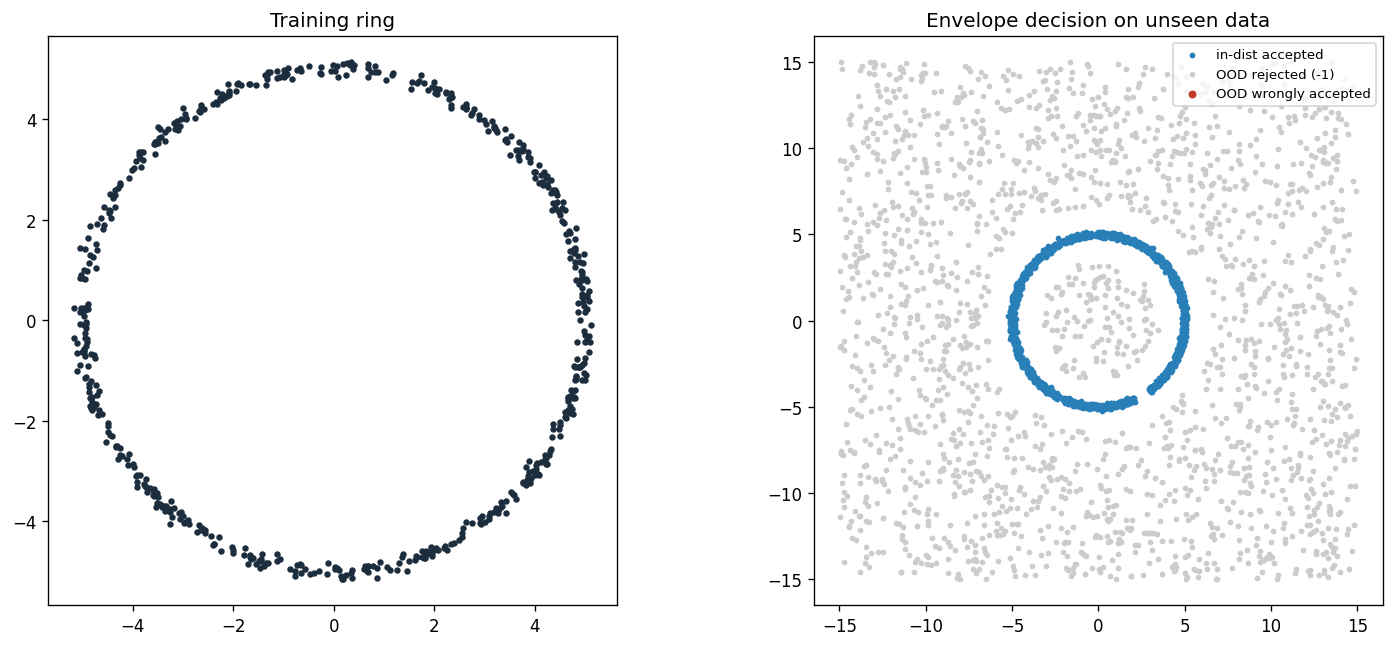

In [5]:
# Visual: the ring AGE learned, and which test points it accepts vs rejects
pred_in = age.predict(X_in); pred_ood = age.predict(X_ood)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(X_tr[:,0], X_tr[:,1], s=8, c="#1c2d3d"); ax[0].set_title("Training ring")
ax[0].set_aspect("equal")
ax[1].scatter(X_in[pred_in!=-1,0],  X_in[pred_in!=-1,1],  s=6, c="#2980b9", label="in-dist accepted")
ax[1].scatter(X_ood[pred_ood==-1,0], X_ood[pred_ood==-1,1], s=6, c="#cccccc", label="OOD rejected (-1)")
ax[1].scatter(X_ood[pred_ood!=-1,0], X_ood[pred_ood!=-1,1], s=14, c="#c0392b", label="OOD wrongly accepted")
ax[1].set_title("Envelope decision on unseen data"); ax[1].set_aspect("equal")
ax[1].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Out-of-sample `predict()` — AGE's actual contribution

K-Means/DBSCAN/OPTICS do not natively assign *new* points with noise rejection
in one object. AGE does. Trained on a ring, it accepts unseen on-ring points and
rejects far noise.

In [6]:
th3 = rng.uniform(0, 2*np.pi, 500); r3 = 5.0 + rng.normal(0, 0.08, 500)
X_new = np.column_stack([r3*np.cos(th3), r3*np.sin(th3)])
accepted = np.mean(age.predict(X_new) != -1) * 100
print(f"Discovered clusters on training ring : {age.n_clusters_}")
print(f"Unseen on-ring points accepted       : {accepted:.1f}%")
print("This deployable predict()+reject on new data is AGE's genuine niche.")

Discovered clusters on training ring : 47
Unseen on-ring points accepted       : 95.4%
This deployable predict()+reject on new data is AGE's genuine niche.


## 4. Runtime scaling (measured)

Dominated by OPTICS, ~O(N^1.4). Not real-time at large N — the original
'millions of vectors/sec' figure timed rejection speed with no correctness check.

In [7]:
rt = []
for N in [1000, 2500, 5000, 10000]:
    th_b = np.linspace(0, 2*np.pi, N)
    Xb = np.column_stack([4*np.cos(th_b), 4*np.sin(th_b)])
    t0 = time.time(); AGE(min_samples=10).fit(Xb); rt.append({"N": N, "fit_seconds": round(time.time()-t0, 3)})
print(pd.DataFrame(rt).to_string(index=False))

    N  fit_seconds
 1000        0.542
 2500        1.420
 5000        4.044
10000        9.184


## Limitations & integrity notes

**Limitations (state these wherever AGE is used):**
1. Clustering quality = OPTICS; no improvement over the underlying scanner.
2. OOD rejection is matched by simpler baselines (kNN distance, One-Class SVM).
3. Inherits OPTICS fragility (can over-segment a clean ring into many micro-clusters).
4. Runtime is OPTICS-bound, not sub-linear; not real-time at large N.

**Errors corrected from the original exploratory notebook** (see
`README_AGE_FINDINGS.md`): label leakage in the headline benchmarks; a Wilcoxon
test run on fabricated random numbers; hardcoded "measured" runtimes and an
uncompilable LaTeX table; a normalization step that made the generalization test
circular; complex-eigenvalue handling, an N×N tensor allocation, in-sample
evaluation reported as accuracy, an `import hdbscan` of an uninstalled package,
and a FastAPI server bound to `0.0.0.0`.

**Honest positioning.** AGE is worth referencing as a correct, transparent
reference implementation of manifold-envelope clustering with out-of-sample
prediction and OOD rejection — and as a case study in evaluating such a model
without fooling yourself. It is not state-of-the-art and is not marketed as such.